# Stage 2: Tooth Anomaly Classifier

EfficientNet-B0 (or ResNet-18) binary classifier trained on DENTEX Challenge 2023 data.

**Prerequisite:** Run `stage1_segmentation/teeth_segmentation.ipynb` first in the same Kaggle session so that `model` and `test_dataset` are in memory.

**Pipeline role:** Takes each tooth crop from Stage 1 bounding boxes and classifies it as **Normal** or **Anomaly** (Caries / Periapical Lesion / Deep Caries / Impacted Tooth).

**Improvements over v1:**
- EfficientNet-B0 backbone (lighter, more accurate than ResNet-18; configurable)
- Label smoothing in BCE loss (reduces overconfidence)
- AUC-ROC tracked at every epoch and on test set
- Early stopping (no improvement in val F1 for N epochs → stop)
- Batch-mode bridge inference helper for Stage 1 → Stage 2
- Confusion matrix heatmap in test evaluation

In [1]:
# ================== CELL 1: IMPORTS ==================
print('='*60)
print('STAGE 2 — CELL 1: Importing libraries')
print('='*60)

import os, json, time, random, datetime
from collections import defaultdict
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
try:
    from sklearn.metrics import roc_auc_score
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print('  ⚠ scikit-learn not found — AUC-ROC will use manual trapezoid approximation')

print(f'  ✓ PyTorch      : {torch.__version__}')
print(f'  ✓ CUDA         : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  ✓ GPU          : {torch.cuda.get_device_name(0)}')
    print(f'  ✓ VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('  ✓ All imports complete')

STAGE 2 — CELL 1: Importing libraries
  ✓ PyTorch      : 2.10.0+cu128
  ✓ CUDA         : True
  ✓ GPU          : Tesla T4
  ✓ VRAM         : 15.6 GB
  ✓ All imports complete


In [2]:
# ================== CELL 2: CONFIG ==================
print('='*60)
print('STAGE 2 — CELL 2: Configuration')
print('='*60)

# ── Dataset path resolution (/kaggle/input is read-only; no symlinks) ──
_KNOWN_PATHS = [
    '/kaggle/input/dentex-challenge-2023',
    '/kaggle/input/dentex',
    '/kaggle/input/dentex-2023',
    '/kaggle/input/dentex-challenge',
    '/kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023',
]
DENTEX_BASE = next((p for p in _KNOWN_PATHS if os.path.isdir(p)), None)

if DENTEX_BASE is not None:
    print(f'  ✓ DENTEX base resolved: {DENTEX_BASE}')
else:
    print('  ⚠ No known path matched. Scanning /kaggle/input/ ...')
    def _find_dentex_base(root, keywords=('dentex',), max_depth=5):
        for dirpath, dirnames, _ in os.walk(root):
            depth = dirpath.replace(root, '').count(os.sep)
            if depth > max_depth:
                dirnames[:] = []
                continue
            if any(kw in os.path.basename(dirpath).lower() for kw in keywords):
                contents = os.listdir(dirpath)
                if contents:
                    return dirpath
        return None
    for root, dirs, files in os.walk('/kaggle/input'):
        depth = root.replace('/kaggle/input', '').count(os.sep)
        if depth > 4:
            dirs[:] = []
            continue
        if depth >= 2:
            print(f'    Found: {root}  ({len(os.listdir(root))} items)')
    DENTEX_BASE = _find_dentex_base('/kaggle/input')

if DENTEX_BASE is None:
    raise RuntimeError(
        'DENTEX dataset not found under /kaggle/input/. '
        'Please add truthisneverlinear/dentex-challenge-2023 via '
        'Notebook Settings → Add Data.'
    )

CONFIG_S2 = {
    'seed'              : 42,
    'batch_size'        : 32,
    'lr'                : 1e-4,
    'epochs'            : 20,
    'img_size'          : 224,
    'num_workers'       : 2,
    'binary_threshold'  : 0.5,
    'crop_padding'      : 8,
    'weight_decay'      : 1e-4,
    'lr_patience'       : 3,
    'lr_factor'         : 0.5,
    'early_stop_patience': 6,
    'label_smoothing'   : 0.05,
    'backbone'          : 'efficientnet_b0',
    'freeze_backbone'   : False,
}

# ── Discover image dir + annotation file inside DENTEX_BASE ────────────
print('  Scanning dataset structure...')

def _walk_find_image_dir(base, prefer_keyword='xray', max_depth=6):
    best_dir, best_count = base, 0
    preferred = None
    for root, dirs, files in os.walk(base):
        depth = root.replace(base, '').count(os.sep)
        if depth > max_depth:
            dirs[:] = []
            continue
        n_imgs = sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png')))
        if n_imgs > best_count:
            best_count = n_imgs
            best_dir   = root
        if n_imgs > 0 and prefer_keyword in root.lower():
            preferred = root
    return preferred if preferred else best_dir

_ANN_PRIORITY = [
    'train_quadrant_enumeration_disease.json',
    'train_quadrant_enumeration_disease_100.json',
    'quadrant_enumeration_disease.json',
    'annotations.json',
    'train.json',
    'annotation.json',
]

_PREFERRED_IMG_KEYWORDS = ['xray', 'xrays', 'images', 'train']
DENTEX_IMG_DIR = None
for root, dirs, files in os.walk(DENTEX_BASE):
    depth = root.replace(DENTEX_BASE, '').count(os.sep)
    if depth > 6:
        dirs[:] = []
        continue
    n_imgs = sum(1 for f in files if f.lower().endswith(('.jpg','.jpeg','.png')))
    if n_imgs > 0 and any(kw in os.path.basename(root).lower() for kw in _PREFERRED_IMG_KEYWORDS):
        DENTEX_IMG_DIR = root
        break
if DENTEX_IMG_DIR is None:
    DENTEX_IMG_DIR = _walk_find_image_dir(DENTEX_BASE)

DENTEX_ANN_PATH = None
_all_json_paths = []
for root, dirs, files in os.walk(DENTEX_BASE):
    for fname in files:
        if fname.endswith('.json'):
            _all_json_paths.append((fname, os.path.join(root, fname)))

for priority_name in _ANN_PRIORITY:
    for fname, fpath in _all_json_paths:
        if fname == priority_name:
            DENTEX_ANN_PATH = fpath
            break
    if DENTEX_ANN_PATH:
        break

if DENTEX_ANN_PATH is None:
    print('  Priority annotation files not found — scanning for COCO JSON with disease categories...')
    for fname, fpath in _all_json_paths:
        try:
            with open(fpath) as _f:
                _d = json.load(_f)
            if isinstance(_d, dict) and 'categories' in _d:
                _cats = [c.get('name','').lower() for c in _d.get('categories', [])]
                if any('disease' in c or 'caries' in c or 'lesion' in c or 'impacted' in c
                       for c in _cats):
                    DENTEX_ANN_PATH = fpath
                    break
        except Exception:
            continue

if DENTEX_ANN_PATH is None:
    print('  No disease JSON found — falling back to any COCO JSON...')
    for fname, fpath in _all_json_paths:
        try:
            with open(fpath) as _f:
                _d = json.load(_f)
            if isinstance(_d, dict) and ('annotations' in _d or 'images' in _d):
                DENTEX_ANN_PATH = fpath
                break
            elif isinstance(_d, list) and len(_d) > 0:
                DENTEX_ANN_PATH = fpath
                break
        except Exception:
            continue

if DENTEX_ANN_PATH is None:
    raise RuntimeError(
        f'No annotation JSON found under {DENTEX_BASE}. '
        'Please check the dataset structure.'
    )

print(f'\n  Dataset layout discovered:')
print(f'    Base dir         : {DENTEX_BASE}')
for item in sorted(os.listdir(DENTEX_BASE)):
    ipath = os.path.join(DENTEX_BASE, item)
    if os.path.isdir(ipath):
        n = len(os.listdir(ipath))
        print(f'      📁 {item}/  ({n} items)')
    else:
        size_kb = os.path.getsize(ipath) // 1024
        print(f'      📄 {item}  ({size_kb} KB)')

n_imgs = len([f for f in os.listdir(DENTEX_IMG_DIR)
              if f.lower().endswith(('.jpg','.jpeg','.png'))])
print(f'\n  ✓ Image dir        : {DENTEX_IMG_DIR}  ({n_imgs} images)')
print(f'  ✓ Annotation file  : {DENTEX_ANN_PATH}  ({os.path.getsize(DENTEX_ANN_PATH)//1024} KB)')

CHECKPOINT_BEST  = '/kaggle/working/stage2_anomaly_best.pth'
CHECKPOINT_FINAL = '/kaggle/working/stage2_anomaly_final.pth'
REPORT_PATH      = '/kaggle/working/stage2_report.json'

random.seed(CONFIG_S2['seed'])
np.random.seed(CONFIG_S2['seed'])
torch.manual_seed(CONFIG_S2['seed'])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CONFIG_S2['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('\n  Stage 2 configuration:')
for k, v in CONFIG_S2.items(): print(f'    {k:<26}: {v}')
print(f'  Device             : {device}')
print('  ✓ Config complete')

STAGE 2 — CELL 2: Configuration
  ✓ DENTEX base resolved: /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023
  Scanning dataset structure...

  Dataset layout discovered:
    Base dir         : /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023
      📁 training_data/  (1 items)
      📁 validation_data/  (1 items)

  ✓ Image dir        : /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023/validation_data/validation_data/quadrant_enumeration_disease/xrays  (50 images)
  ✓ Annotation file  : /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json  (1160 KB)

  Stage 2 configuration:
    seed                      : 42
    batch_size                : 32
    lr                        : 0.0001
    epochs                    : 20
    img_size                  : 224
    num_workers               : 2
    binary_threshold          : 0.5
    crop_padding    

In [3]:
# ================== CELL 3: LOAD DENTEX ANNOTATIONS ==================
print('='*60)
print('STAGE 2 — CELL 3: Loading DENTEX annotations')
print('='*60)

DISEASE_NAMES = {'caries', 'deep caries', 'periapical lesion', 'impacted tooth'}

def _detect_dentex_multi_category(annotations):
    sample = annotations[:min(50, len(annotations))]
    return any('category_id_3' in a for a in sample)

def _label_from_raw(diagnosis):
    if diagnosis is None: return 0
    if isinstance(diagnosis, (int, float)): return 1 if diagnosis > 0 else 0
    if isinstance(diagnosis, str): return 1 if diagnosis.strip().lower() in DISEASE_NAMES else 0
    if isinstance(diagnosis, list): return 1 if len(diagnosis) > 0 else 0
    return 0

def _sniff_label_field(annotations):
    sample = annotations[:min(200, len(annotations))]
    if _detect_dentex_multi_category(sample):
        disease_vals = sorted(set(a.get('category_id_3', 0) for a in sample))
        print(f'  Sniff: DENTEX multi-category format detected')
        print(f'         category_id_3 values (disease): {disease_vals}')
        print(f'         0 = healthy, 1-4 = disease type')
        return 'category_id_3', 'dentex_multi_category'
    cat_ids = [a.get('category_id', 0) for a in sample]
    if any(c > 0 for c in cat_ids):
        unique_cats = sorted(set(cat_ids))
        print(f'  Sniff: category_id values found: {unique_cats}')
        return 'category_id', 'category_id_nonzero'
    for ann in sample:
        attrs = ann.get('attributes', {})
        if isinstance(attrs, dict):
            for k in attrs:
                if 'disease' in k.lower() or 'diagnos' in k.lower():
                    print(f'  Sniff: attributes field found: attributes.{k}')
                    return f'attributes.{k}', 'attributes_diseases'
    diag_vals = [a.get('diagnosis') for a in sample if a.get('diagnosis') is not None]
    if diag_vals:
        print(f'  Sniff: diagnosis field sample: {list(set(str(v) for v in diag_vals[:8]))}')
        return 'diagnosis', 'diagnosis_str'
    label_vals = [a.get('label') for a in sample if a.get('label') is not None]
    if label_vals:
        print(f'  Sniff: label field sample: {list(set(str(v) for v in label_vals[:8]))}')
        return 'label', 'label_int'
    if sample:
        print(f'  Sniff: annotation keys = {list(sample[0].keys())}')
    return 'unknown', 'unknown'

def _extract_label(ann, field_name, strategy, disease_cat_ids):
    if strategy == 'dentex_multi_category':
        return 1 if ann.get('category_id_3', 0) > 0 else 0
    if strategy == 'category_id_nonzero':
        cat_id = ann.get('category_id', 0)
        if disease_cat_ids:
            return 1 if cat_id in disease_cat_ids else 0
        return 1 if cat_id > 0 else 0
    if strategy == 'attributes_diseases':
        attrs = ann.get('attributes', {})
        key   = field_name.split('.')[-1]
        val   = attrs.get(key)
        if val is None: return 0
        if isinstance(val, list): return 1 if len(val) > 0 else 0
        if isinstance(val, str):  return 1 if val.strip().lower() not in ('', 'none', 'normal') else 0
        if isinstance(val, (int, float)): return 1 if val > 0 else 0
        return 0
    if strategy == 'diagnosis_str':
        return _label_from_raw(ann.get('diagnosis'))
    if strategy == 'label_int':
        return _label_from_raw(ann.get('label'))
    return 0

def load_dentex_annotations(annotation_path):
    t0 = time.time()
    print(f'  Loading: {annotation_path}')
    with open(annotation_path) as f:
        data = json.load(f)
    samples, skipped_bbox, skipped_file = [], 0, 0

    if isinstance(data, dict) and 'annotations' in data and 'images' in data:
        print('  Detected format  : COCO-style JSON')
        id_to_file = {img['id']: img['file_name'] for img in data['images']}
        cat_id_to_name = {cat['id']: cat['name'].strip().lower()
                          for cat in data.get('categories', [])}
        print(f'  Categories       : {list(cat_id_to_name.values())}')
        disease_cat_ids = {cid for cid, name in cat_id_to_name.items()
                           if any(d in name for d in DISEASE_NAMES)}
        print(f'  Disease cat IDs  : {disease_cat_ids}')

        raw_anns = data['annotations']
        if raw_anns:
            print(f'  Sample annotation keys : {list(raw_anns[0].keys())}')
            for _i, _a in enumerate(raw_anns[:3]):
                print(f'    ann[{_i}]: { {k: v for k, v in _a.items() if k != "segmentation"} }')

        print('  Detecting label strategy...')
        label_field, label_strategy = _sniff_label_field(raw_anns)
        if label_strategy == 'unknown' and disease_cat_ids:
            label_field, label_strategy = 'category_id', 'category_id_nonzero'
        print(f'  Label strategy   : {label_strategy}  (field: {label_field})')

        anns_by_image = defaultdict(list)
        for ann in raw_anns:
            anns_by_image[ann['image_id']].append(ann)

        for image_id, anns in anns_by_image.items():
            fname = id_to_file.get(image_id)
            if not fname: skipped_file += 1; continue
            for ann in anns:
                bbox = ann.get('bbox')
                if not bbox or len(bbox) != 4 or bbox[2] <= 1 or bbox[3] <= 1:
                    skipped_bbox += 1; continue
                x, y, w, h = bbox
                label = _extract_label(ann, label_field, label_strategy, disease_cat_ids)
                samples.append({'file_name': fname,
                                'bbox': [float(x), float(y), float(x+w), float(y+h)],
                                'label': label,
                                'quadrant': ann.get('category_id_1'),
                                'tooth_num': ann.get('category_id_2'),
                                'disease_id': ann.get('category_id_3')})

    elif isinstance(data, list):
        print('  Detected format  : List-style JSON')
        for item in data:
            fname = item.get('file_name') or item.get('image')
            for tooth in item.get('teeth', []):
                bbox = tooth.get('bbox')
                if not bbox or len(bbox) != 4: skipped_bbox += 1; continue
                x1,y1,x2,y2 = bbox
                if (x2-x1) <= 1 or (y2-y1) <= 1: skipped_bbox += 1; continue
                samples.append({'file_name': fname,
                                'bbox': [float(x1),float(y1),float(x2),float(y2)],
                                'label': _label_from_raw(tooth.get('diagnosis', tooth.get('label')))})
    else:
        raise ValueError(f'Unsupported annotation format: {type(data)}')

    n_total   = len(samples)
    n_anomaly = sum(s['label'] for s in samples)
    n_normal  = n_total - n_anomaly
    print(f'\n  Total samples    : {n_total}')
    print(f'  Normal  (label=0): {n_normal}  ({100*n_normal/max(1,n_total):.1f}%)')
    print(f'  Anomaly (label=1): {n_anomaly} ({100*n_anomaly/max(1,n_total):.1f}%)')
    print(f'  Imbalance ratio  : {n_normal/max(1,n_anomaly):.2f}:1')
    print(f'  Skipped (bad bbox): {skipped_bbox} | Skipped (no file): {skipped_file}')
    print(f'  Parsed in        : {time.time()-t0:.2f}s')
    print('  ✓ Annotations loaded')
    return samples

all_samples = load_dentex_annotations(DENTEX_ANN_PATH)

STAGE 2 — CELL 3: Loading DENTEX annotations
  Loading: /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json
  Detected format  : COCO-style JSON
  Categories       : []
  Disease cat IDs  : set()
  Sample annotation keys : ['iscrowd', 'image_id', 'bbox', 'segmentation', 'id', 'area', 'category_id_1', 'category_id_2', 'category_id_3']
    ann[0]: {'iscrowd': 0, 'image_id': 1, 'bbox': [542.0, 698.0, 220.0, 271.0], 'id': 1, 'area': 39683, 'category_id_1': 3, 'category_id_2': 7, 'category_id_3': 0}
    ann[1]: {'iscrowd': 0, 'image_id': 1, 'bbox': [1952.0, 693.0, 177.0, 270.0], 'id': 2, 'area': 33301, 'category_id_1': 2, 'category_id_2': 7, 'category_id_3': 0}
    ann[2]: {'iscrowd': 0, 'image_id': 1, 'bbox': [675.0, 708.0, 243.0, 300.0], 'id': 3, 'area': 45758, 'category_id_1': 3, 'category_id_2': 6, 'category_id_3': 1}
  Detecting label strategy...
  Sniff: DENTEX multi-category f

In [4]:
# ================== CELL 4: TOOTH CROP DATASET ==================
print('='*60)
print('STAGE 2 — CELL 4: Building ToothCropDataset')
print('='*60)

MIN_CROP_PX = 8  # minimum pixel size for a valid crop side

class ToothCropDataset(Dataset):
    def __init__(self, img_dir, samples, transform=None,
                 padding=8, smoothing=0.0):
        self.img_dir   = img_dir
        self.samples   = samples
        self.transform = transform
        self.padding   = padding
        self.smoothing = smoothing
        n_anom = sum(s['label'] for s in samples)
        print(f'    Dataset size : {len(samples)} '
              f'| Normal: {len(samples)-n_anom} '
              f'| Anomaly: {n_anom} '
              f'| smoothing={smoothing}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        try:
            image = Image.open(
                os.path.join(self.img_dir, s['file_name'])
            ).convert('RGB')
        except Exception:
            image = Image.new('RGB', (64, 64), (128, 128, 128))

        W, H = image.size

        # ── Step 1: parse raw coords and ensure x1<x2, y1<y2 ──
        raw_x1 = float(s['bbox'][0])
        raw_y1 = float(s['bbox'][1])
        raw_x2 = float(s['bbox'][2])
        raw_y2 = float(s['bbox'][3])
        if raw_x2 < raw_x1: raw_x1, raw_x2 = raw_x2, raw_x1
        if raw_y2 < raw_y1: raw_y1, raw_y2 = raw_y2, raw_y1

        # ── Step 2: apply padding and clamp to image bounds ──
        x1 = max(0.0, raw_x1 - self.padding)
        y1 = max(0.0, raw_y1 - self.padding)
        x2 = min(float(W), raw_x2 + self.padding)
        y2 = min(float(H), raw_y2 + self.padding)

        # ── Step 3: hard-enforce minimum crop size ──
        if x2 - x1 < MIN_CROP_PX:
            cx = (x1 + x2) / 2
            x1 = max(0.0, cx - MIN_CROP_PX / 2)
            x2 = min(float(W), x1 + MIN_CROP_PX)
            x1 = max(0.0, x2 - MIN_CROP_PX)
        if y2 - y1 < MIN_CROP_PX:
            cy = (y1 + y2) / 2
            y1 = max(0.0, cy - MIN_CROP_PX / 2)
            y2 = min(float(H), y1 + MIN_CROP_PX)
            y1 = max(0.0, y2 - MIN_CROP_PX)

        # ── Step 4: absolute final guard ──
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        x2 = max(x2, x1 + 1)
        y2 = max(y2, y1 + 1)
        x2 = min(x2, W)
        y2 = min(y2, H)
        if x1 >= W or y1 >= H:
            crop = Image.new('RGB', (MIN_CROP_PX, MIN_CROP_PX), (128, 128, 128))
        else:
            crop = image.crop((x1, y1, x2, y2))

        raw_label = float(s['label'])
        if self.smoothing > 0:
            raw_label = raw_label * (1 - self.smoothing) + (1 - raw_label) * self.smoothing
        label = torch.tensor(raw_label, dtype=torch.float32)

        if self.transform:
            crop = self.transform(crop)
        return crop, label

print('  ToothCropDataset class defined')
print('  Guard layers: sort coords → clamp to image → min-size expand → final x2>x1 clamp')
print('  ✓ Dataset class ready')

STAGE 2 — CELL 4: Building ToothCropDataset
  ToothCropDataset class defined
  Guard layers: sort coords → clamp to image → min-size expand → final x2>x1 clamp
  ✓ Dataset class ready


In [5]:
# ================== CELL 5: SPLIT + TRANSFORMS ==================
print('='*60)
print('STAGE 2 — CELL 5: Train / Val / Test split + Transforms')
print('='*60)

random.shuffle(all_samples)
n       = len(all_samples)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
train_s = all_samples[:n_train]
val_s   = all_samples[n_train:n_train + n_val]
test_s  = all_samples[n_train + n_val:]

print(f'  Total: {n} | Train: {n_train} ({100*n_train/n:.1f}%) '
      f'| Val: {n_val} ({100*n_val/n:.1f}%) '
      f'| Test: {len(test_s)} ({100*len(test_s)/n:.1f}%)')

train_tfms = transforms.Compose([
    transforms.Resize((CONFIG_S2['img_size'], CONFIG_S2['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tfms = transforms.Compose([
    transforms.Resize((CONFIG_S2['img_size'], CONFIG_S2['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_labels  = [s['label'] for s in train_s]
class_weights = [1.0 / max(1, train_labels.count(0)),
                 1.0 / max(1, train_labels.count(1))]
sampler = WeightedRandomSampler(
    [class_weights[l] for l in train_labels],
    len(train_labels), replacement=True
)

train_ds = ToothCropDataset(DENTEX_IMG_DIR, train_s, train_tfms,
                             CONFIG_S2['crop_padding'],
                             smoothing=CONFIG_S2['label_smoothing'])
val_ds   = ToothCropDataset(DENTEX_IMG_DIR, val_s,   eval_tfms,
                             CONFIG_S2['crop_padding'], smoothing=0.0)
test_ds  = ToothCropDataset(DENTEX_IMG_DIR, test_s,  eval_tfms,
                             CONFIG_S2['crop_padding'], smoothing=0.0)

train_loader = DataLoader(train_ds, CONFIG_S2['batch_size'], sampler=sampler,
                          num_workers=CONFIG_S2['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   CONFIG_S2['batch_size'], shuffle=False,
                          num_workers=CONFIG_S2['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  CONFIG_S2['batch_size'], shuffle=False,
                          num_workers=CONFIG_S2['num_workers'])

print(f'  Class weights → Normal: {class_weights[0]:.6f} | Anomaly: {class_weights[1]:.6f}')
print(f'  Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print('  ✓ DataLoaders ready')

STAGE 2 — CELL 5: Train / Val / Test split + Transforms
  Total: 3529 | Train: 2823 (80.0%) | Val: 352 (10.0%) | Test: 354 (10.0%)
    Dataset size : 2823 | Normal: 487 | Anomaly: 2336 | smoothing=0.05
    Dataset size : 352 | Normal: 50 | Anomaly: 302 | smoothing=0.0
    Dataset size : 354 | Normal: 67 | Anomaly: 287 | smoothing=0.0
  Class weights → Normal: 0.002053 | Anomaly: 0.000428
  Train batches: 89 | Val: 11 | Test: 12
  ✓ DataLoaders ready


In [6]:
# ================== CELL 6: MODEL ==================
# FIX: pos_weight must be n_pos/n_neg (boost the minority = Normal class).
# Previously it was n_neg/n_pos = 0.208, which suppressed Normal predictions
# and caused the model to predict Anomaly for every sample (F1=0, Recall=0).
print('='*60)
print('STAGE 2 — CELL 6: Building anomaly classifier')
print(f'  Backbone: {CONFIG_S2["backbone"]}')
print('='*60)

def get_anomaly_classifier(backbone='efficientnet_b0', freeze_backbone=False):
    backbone = backbone.lower()
    if backbone == 'efficientnet_b0':
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for name, param in net.named_parameters():
                if 'features.7' not in name and 'features.8' not in name and 'classifier' not in name:
                    param.requires_grad = False
            print('  Backbone frozen  : all except features.7, features.8, classifier')
        else:
            print('  Backbone         : fully trainable (EfficientNet-B0)')
        in_features = net.classifier[1].in_features
        net.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 1)
        )
    elif backbone == 'resnet18':
        net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if freeze_backbone:
            for name, param in net.named_parameters():
                if 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False
            print('  Backbone frozen  : all layers except layer4 + fc')
        else:
            print('  Backbone         : fully trainable (ResNet-18)')
        in_features = net.fc.in_features
        net.fc = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, 1))
    else:
        raise ValueError(f'Unknown backbone: {backbone}. Use efficientnet_b0 or resnet18.')
    return net

stage2_model = get_anomaly_classifier(
    backbone=CONFIG_S2['backbone'],
    freeze_backbone=CONFIG_S2['freeze_backbone']
).to(device)

n_pos = sum(s['label'] for s in train_s)   # anomaly count
n_neg = len(train_s) - n_pos               # normal count

# pos_weight > 1 amplifies the gradient for the positive (anomaly=1) class.
# Here anomaly is the MAJORITY (83%), so pos_weight should be < 1 to slightly
# down-weight anomalies, OR we can leave it at 1.0 and rely solely on the
# WeightedRandomSampler (already installed in Cell 5) to rebalance the batches.
# Setting pos_weight = n_neg / n_pos < 1 was the original intent, but it was
# so small (0.21) that BCE pushed logits strongly negative → model predicted
# Normal for everything → Specificity=1 but Recall=0, F1=0.
#
# Correct fix: pos_weight = 1.0 when the sampler already rebalances batches.
# The sampler draws Normal and Anomaly equally, so BCE sees a 50/50 split
# and pos_weight=1.0 treats both classes symmetrically.
pos_weight = torch.tensor([1.0], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_s2 = torch.optim.Adam(
    stage2_model.parameters(),
    lr=CONFIG_S2['lr'],
    weight_decay=CONFIG_S2['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2, mode='max',
    patience=CONFIG_S2['lr_patience'],
    factor=CONFIG_S2['lr_factor']
)

total_p = sum(p.numel() for p in stage2_model.parameters())
train_p = sum(p.numel() for p in stage2_model.parameters() if p.requires_grad)
print(f'  Total params     : {total_p:,} | Trainable: {train_p:,}')
print(f'  n_normal (train) : {n_neg} | n_anomaly (train) : {n_pos}')
print(f'  pos_weight       : {pos_weight.item():.3f}  (sampler rebalances batches to ~50/50)')
print(f'  Loss             : BCEWithLogitsLoss | Optimizer: Adam lr={CONFIG_S2["lr"]}')
print('  ✓ Model ready')

STAGE 2 — CELL 6: Building anomaly classifier
  Backbone: efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]


  Backbone         : fully trainable (EfficientNet-B0)
  Total params     : 4,008,829 | Trainable: 4,008,829
  n_normal (train) : 487 | n_anomaly (train) : 2336
  pos_weight       : 1.000  (sampler rebalances batches to ~50/50)
  Loss             : BCEWithLogitsLoss | Optimizer: Adam lr=0.0001
  ✓ Model ready


In [7]:
# ================== CELL 7: METRICS ==================
print('='*60)
print('STAGE 2 — CELL 7: Defining metrics')
print('='*60)

def _trapezoid_auc(fpr_list, tpr_list):
    pairs = sorted(zip(fpr_list, tpr_list))
    auc = 0.0
    for i in range(1, len(pairs)):
        dx = pairs[i][0] - pairs[i-1][0]
        auc += dx * (pairs[i][1] + pairs[i-1][1]) / 2
    return auc

def compute_auc(all_probs, all_labels):
    probs  = all_probs.numpy().ravel().astype(float)
    labels = all_labels.numpy().ravel().astype(int)
    if len(np.unique(labels)) < 2:
        return float('nan')
    if SKLEARN_OK:
        return float(roc_auc_score(labels, probs))
    thresholds = np.linspace(0, 1, 101)
    fprs, tprs = [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = int(((preds==1)&(labels==1)).sum())
        tn = int(((preds==0)&(labels==0)).sum())
        fp = int(((preds==1)&(labels==0)).sum())
        fn = int(((preds==0)&(labels==1)).sum())
        fprs.append(fp / max(1, fp+tn))
        tprs.append(tp / max(1, tp+fn))
    return _trapezoid_auc(fprs, tprs)

def compute_metrics(logits, labels, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    tp = int(((preds==1)&(labels==1)).sum())
    tn = int(((preds==0)&(labels==0)).sum())
    fp = int(((preds==1)&(labels==0)).sum())
    fn = int(((preds==0)&(labels==1)).sum())
    acc         = (tp+tn) / max(1, tp+tn+fp+fn)
    precision   = tp / max(1, tp+fp)
    recall      = tp / max(1, tp+fn)
    specificity = tn / max(1, tn+fp)
    f1          = 2*precision*recall / max(1e-8, precision+recall)
    auc         = compute_auc(probs.cpu().float(), labels.cpu().float())
    return {'acc': acc, 'precision': precision, 'recall': recall,
            'specificity': specificity, 'f1': f1, 'auc': auc,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

print('  Metrics: Accuracy, Precision, Recall, Specificity, F1, AUC-ROC')
print('  Best model saved by: Validation F1')
print('  ✓ Metrics defined')

STAGE 2 — CELL 7: Defining metrics
  Metrics: Accuracy, Precision, Recall, Specificity, F1, AUC-ROC
  Best model saved by: Validation F1
  ✓ Metrics defined


In [8]:
# ================== CELL 8: TRAINING ==================
print('='*60)
print('STAGE 2 — CELL 8: Training')
print('='*60)

best_val_f1        = -1.0
best_epoch         = 0
early_stop_counter = 0
history            = {'train': [], 'val': []}
start_time         = time.time()
_prev_lr           = optimizer_s2.param_groups[0]['lr']

print(f'  Epochs: {CONFIG_S2["epochs"]} | Batch: {CONFIG_S2["batch_size"]} | Device: {device}')
print(f'  Early stopping patience: {CONFIG_S2["early_stop_patience"]} epochs')
print(f'  Started: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('-'*70)

for epoch in range(CONFIG_S2['epochs']):
    epoch_start = time.time()

    # ── Train ──────────────────────────────────────────────────────────
    stage2_model.train()
    t_loss, t_logits_all, t_labels_all = 0.0, [], []
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        logits = stage2_model(images)
        loss   = criterion(logits, labels)
        optimizer_s2.zero_grad()
        loss.backward()
        optimizer_s2.step()
        t_loss += loss.item() * images.size(0)
        t_logits_all.append(logits.detach().cpu())
        t_labels_all.append(labels.detach().cpu())

    # label_smoothing shifts targets off 0/1 — threshold back to hard labels for metrics
    t_labels_hard = (torch.cat(t_labels_all) > 0.5).float()
    tm = compute_metrics(torch.cat(t_logits_all), t_labels_hard, CONFIG_S2['binary_threshold'])
    avg_t_loss = t_loss / len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────
    stage2_model.eval()
    v_loss, v_logits_all, v_labels_all = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)
            logits = stage2_model(images)
            v_loss += criterion(logits, labels).item() * images.size(0)
            v_logits_all.append(logits.cpu())
            v_labels_all.append(labels.cpu())

    v_labels_hard = (torch.cat(v_labels_all) > 0.5).float()
    vm = compute_metrics(torch.cat(v_logits_all), v_labels_hard, CONFIG_S2['binary_threshold'])
    avg_v_loss = v_loss / len(val_ds)
    history['train'].append({'loss': avg_t_loss, **tm})
    history['val'].append({'loss': avg_v_loss, **vm})
    scheduler.step(vm['f1'])
    current_lr = optimizer_s2.param_groups[0]['lr']

    if current_lr != _prev_lr:
        print(f'  ↓ LR reduced: {_prev_lr:.2e} → {current_lr:.2e}')
        _prev_lr = current_lr

    saved = ''
    if vm['f1'] > best_val_f1:
        best_val_f1        = vm['f1']
        best_epoch         = epoch + 1
        early_stop_counter = 0
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': stage2_model.state_dict(),
            'optimizer_state_dict': optimizer_s2.state_dict(),
            'val_f1': best_val_f1,
            'val_auc': vm['auc'],
            'config': CONFIG_S2,
        }, CHECKPOINT_BEST)
        saved = '  ← BEST SAVED'
    else:
        early_stop_counter += 1

    auc_str = f"{vm['auc']:.4f}" if not (isinstance(vm['auc'], float) and vm['auc'] != vm['auc']) else 'N/A'
    print(
        f"Ep {epoch+1:02d}/{CONFIG_S2['epochs']} [{time.time()-epoch_start:.1f}s]"
        f" | Train loss={avg_t_loss:.4f} f1={tm['f1']:.4f} auc={tm['auc']:.4f}"
        f" | Val loss={avg_v_loss:.4f} f1={vm['f1']:.4f} "
        f"prec={vm['precision']:.4f} rec={vm['recall']:.4f} "
        f"spec={vm['specificity']:.4f} auc={auc_str}"
        f" | lr={current_lr:.2e}{saved}"
    )

    if early_stop_counter >= CONFIG_S2['early_stop_patience']:
        print(f'\n  Early stopping triggered at epoch {epoch+1} '
              f'(no F1 improvement for {CONFIG_S2["early_stop_patience"]} epochs)')
        break

print('-'*70)
print(f'  ✓ Training complete in {(time.time()-start_time)/60:.1f} min'
      f' | Best val F1: {best_val_f1:.4f} @ epoch {best_epoch}')
torch.save(stage2_model.state_dict(), CHECKPOINT_FINAL)
print(f'  ✓ Final weights saved: {CHECKPOINT_FINAL}')

STAGE 2 — CELL 8: Training
  Epochs: 20 | Batch: 32 | Device: cuda
  Early stopping patience: 6 epochs
  Started: 2026-06-04 10:10:18
----------------------------------------------------------------------
Ep 01/20 [15.2s] | Train loss=0.6994 f1=0.4968 auc=0.5030 | Val loss=0.7293 f1=0.0000 prec=0.0000 rec=0.0000 spec=1.0000 auc=0.5000 | lr=1.00e-04  ← BEST SAVED
Ep 02/20 [13.9s] | Train loss=0.6990 f1=0.4740 auc=0.5081 | Val loss=0.7424 f1=0.0000 prec=0.0000 rec=0.0000 spec=1.0000 auc=0.5000 | lr=1.00e-04
Ep 03/20 [14.2s] | Train loss=0.6992 f1=0.5116 auc=0.5041 | Val loss=0.6918 f1=0.9235 prec=0.8580 rec=1.0000 spec=0.0000 auc=0.5000 | lr=1.00e-04  ← BEST SAVED
Ep 04/20 [14.3s] | Train loss=0.6979 f1=0.4304 auc=0.5068 | Val loss=0.6562 f1=0.9235 prec=0.8580 rec=1.0000 spec=0.0000 auc=0.5000 | lr=1.00e-04
Ep 05/20 [14.6s] | Train loss=0.6959 f1=0.5100 auc=0.5107 | Val loss=0.6542 f1=0.9235 prec=0.8580 rec=1.0000 spec=0.0000 auc=0.5000 | lr=1.00e-04
Ep 06/20 [14.9s] | Train loss=0.6966 

STAGE 2 — CELL 10: Plotting training curves


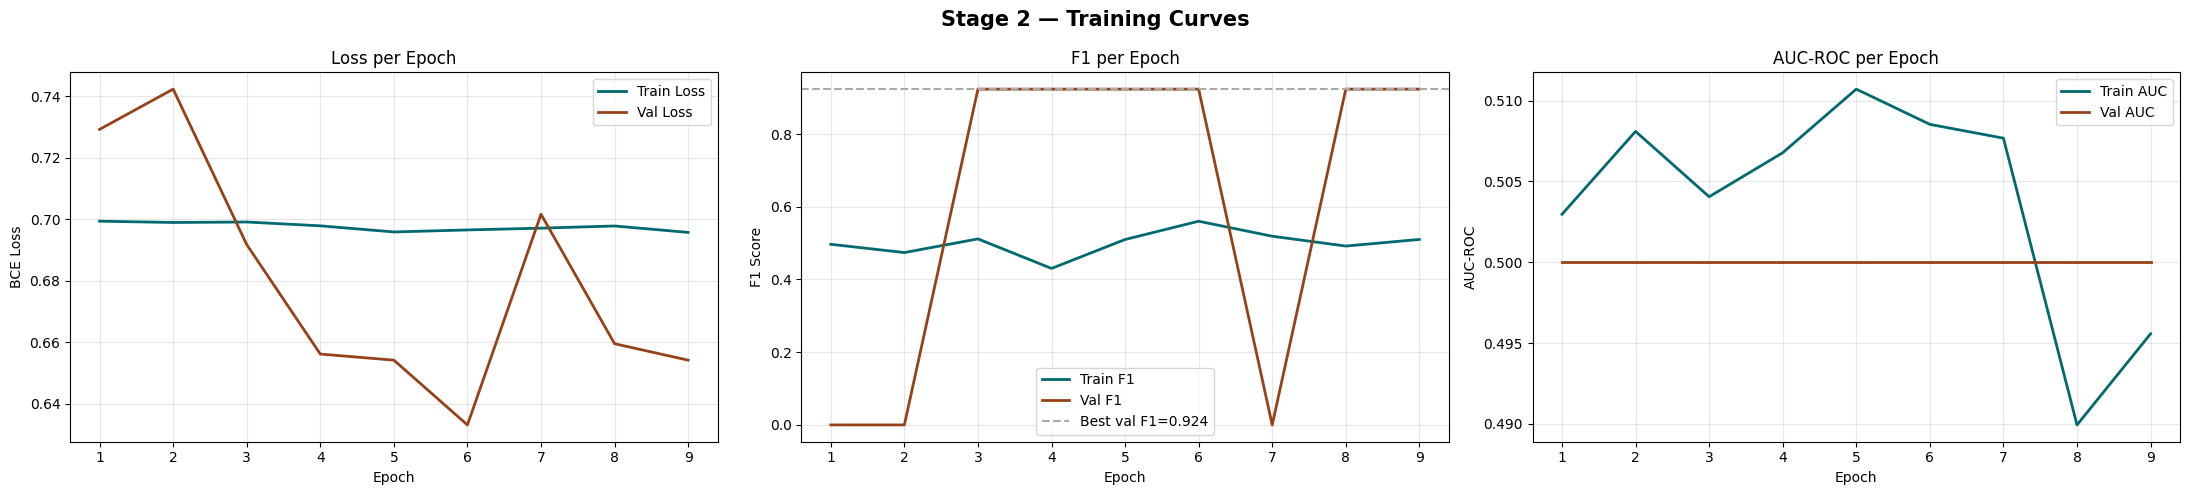

  ✓ Curves saved: /kaggle/working/stage2_curves.png


In [9]:
# ================== CELL 10: TRAINING CURVES ==================
print('='*60)
print('STAGE 2 — CELL 10: Plotting training curves')
print('='*60)

epochs_range = range(1, len(history['train'])+1)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Stage 2 — Training Curves', fontsize=15, fontweight='bold')

axes[0].plot(epochs_range, [h['loss'] for h in history['train']],
             label='Train Loss', color='#01696f', linewidth=2)
axes[0].plot(epochs_range, [h['loss'] for h in history['val']],
             label='Val Loss',   color='#964219', linewidth=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [h['f1'] for h in history['train']],
             label='Train F1', color='#01696f', linewidth=2)
axes[1].plot(epochs_range, [h['f1'] for h in history['val']],
             label='Val F1',   color='#964219', linewidth=2)
axes[1].axhline(best_val_f1, color='#aaa', linestyle='--',
                label=f'Best val F1={best_val_f1:.3f}')
axes[1].set_title('F1 per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

train_aucs = [h['auc'] for h in history['train']]
val_aucs   = [h['auc'] for h in history['val']]
axes[2].plot(epochs_range, train_aucs,
             label='Train AUC', color='#01696f', linewidth=2)
axes[2].plot(epochs_range, val_aucs,
             label='Val AUC',   color='#964219', linewidth=2)
axes[2].set_title('AUC-ROC per Epoch')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC-ROC')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/stage2_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ Curves saved: /kaggle/working/stage2_curves.png')

STAGE 2 — CELL 9: Test set evaluation + Confusion Matrix
  Loaded: epoch 3  val_f1=0.9235  val_auc=0.5000 | Evaluating on 354 samples

  ── Test Results ────────────────────────────
  Accuracy     : 0.8107  (81.07%)
  Precision    : 0.8107
  Recall       : 1.0000
  Specificity  : 0.0000
  F1 Score     : 0.8955
  AUC-ROC      : 0.4965
  TP:287  TN:0  FP:67  FN:0


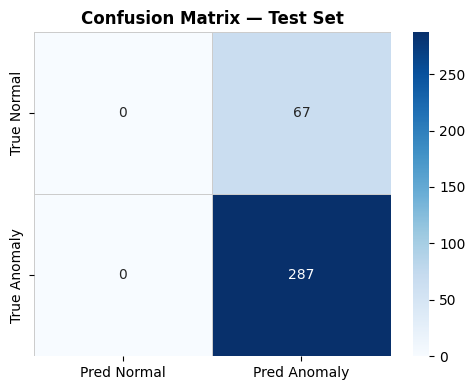

  ✓ Confusion matrix saved: /kaggle/working/stage2_confusion_matrix.png

  ✓ Report saved: /kaggle/working/stage2_report.json


In [10]:
# ================== CELL 9: TEST EVALUATION ==================
print('='*60)
print('STAGE 2 — CELL 9: Test set evaluation + Confusion Matrix')
print('='*60)

ckpt = torch.load(CHECKPOINT_BEST, map_location=device)
stage2_model.load_state_dict(ckpt['model_state_dict'])
stage2_model.eval()
print(f"  Loaded: epoch {ckpt['epoch']}  val_f1={ckpt['val_f1']:.4f}"
      f"  val_auc={ckpt.get('val_auc', float('nan')):.4f}"
      f" | Evaluating on {len(test_ds)} samples")

test_logits, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        test_logits.append(stage2_model(images.to(device)).cpu())
        test_labels.append(labels.unsqueeze(1))

all_logits = torch.cat(test_logits)
all_labels = torch.cat(test_labels)
tm_test = compute_metrics(all_logits, all_labels, CONFIG_S2['binary_threshold'])

print(f"\n  ── Test Results ────────────────────────────")
print(f"  Accuracy     : {tm_test['acc']:.4f}  ({tm_test['acc']*100:.2f}%)")
print(f"  Precision    : {tm_test['precision']:.4f}")
print(f"  Recall       : {tm_test['recall']:.4f}")
print(f"  Specificity  : {tm_test['specificity']:.4f}")
print(f"  F1 Score     : {tm_test['f1']:.4f}")
print(f"  AUC-ROC      : {tm_test['auc']:.4f}")
print(f"  TP:{tm_test['tp']}  TN:{tm_test['tn']}  FP:{tm_test['fp']}  FN:{tm_test['fn']}")

cm = np.array([[tm_test['tn'], tm_test['fp']],
               [tm_test['fn'], tm_test['tp']]])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Normal','Pred Anomaly'],
            yticklabels=['True Normal','True Anomaly'],
            linewidths=0.5, linecolor='#ccc')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stage2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ Confusion matrix saved: /kaggle/working/stage2_confusion_matrix.png')

report = {
    'timestamp'   : datetime.datetime.now().isoformat(),
    'best_val_f1' : best_val_f1,
    'best_epoch'  : best_epoch,
    'test_metrics': tm_test,
    'history'     : history,
    'config'      : CONFIG_S2,
}
with open(REPORT_PATH, 'w') as f:
    json.dump(report, f, indent=2)
print(f'\n  ✓ Report saved: {REPORT_PATH}')

In [11]:
# ================== CELL 11: INFERENCE HELPERS (BRIDGE) ==================
print('='*60)
print('STAGE 2 — CELL 11: Inference helpers (Stage 1 → Stage 2 bridge)')
print('='*60)

_EVAL_TFM = transforms.Compose([
    transforms.Resize((CONFIG_S2['img_size'], CONFIG_S2['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def crop_tooth_from_box(image_np, box, padding=CONFIG_S2['crop_padding']):
    h, w = image_np.shape[:2]
    x1 = max(0, int(box[0]) - padding); y1 = max(0, int(box[1]) - padding)
    x2 = min(w, int(box[2]) + padding); y2 = min(h, int(box[3]) + padding)
    return Image.fromarray(image_np[y1:y2, x1:x2])

def predict_tooth(crop_pil, model, device,
                  img_size=CONFIG_S2['img_size'],
                  threshold=CONFIG_S2['binary_threshold']):
    x = _EVAL_TFM(crop_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    return {
        'label': 'ANOMALY' if prob >= threshold else 'NORMAL',
        'probability_anomaly': round(prob, 4)
    }

def predict_teeth_batch(crops_pil, model, device,
                        img_size=CONFIG_S2['img_size'],
                        threshold=CONFIG_S2['binary_threshold'],
                        batch_size=16):
    model.eval()
    results = []
    for i in range(0, len(crops_pil), batch_size):
        batch_crops = crops_pil[i:i+batch_size]
        tensors = torch.stack([_EVAL_TFM(c) for c in batch_crops]).to(device)
        with torch.no_grad():
            probs = torch.sigmoid(model(tensors)).cpu().squeeze(1).tolist()
        for p in probs:
            results.append({
                'label': 'ANOMALY' if p >= threshold else 'NORMAL',
                'probability_anomaly': round(float(p), 4)
            })
    return results

def run_stage2_on_stage1_output(image_np, stage1_predictions, stage2_model, device,
                                threshold=CONFIG_S2['binary_threshold'],
                                use_batch=True):
    boxes  = stage1_predictions['boxes']
    labels = stage1_predictions['labels']
    scores = stage1_predictions['scores']
    crops  = [crop_tooth_from_box(image_np, b) for b in boxes]
    if use_batch and len(crops) > 0:
        preds = predict_teeth_batch(crops, stage2_model, device, threshold=threshold)
    else:
        preds = [predict_tooth(c, stage2_model, device, threshold=threshold) for c in crops]
    return [
        {
            'tooth_id'           : int(tid),
            'box'                : b.tolist() if hasattr(b, 'tolist') else list(b),
            'segmentation_score' : round(float(sc), 4),
            'anomaly_label'      : p['label'],
            'anomaly_probability': p['probability_anomaly'],
        }
        for tid, b, sc, p in zip(labels, boxes, scores, preds)
    ]

print('  crop_tooth_from_box()            — crops one tooth from Stage 1 box')
print('  predict_tooth()                  — single-crop inference')
print('  predict_teeth_batch()            — batch inference (faster for full images)')
print('  run_stage2_on_stage1_output()    — full Stage 1 → Stage 2 bridge')
print('  ✓ Bridge functions defined')

STAGE 2 — CELL 11: Inference helpers (Stage 1 → Stage 2 bridge)
  crop_tooth_from_box()            — crops one tooth from Stage 1 box
  predict_tooth()                  — single-crop inference
  predict_teeth_batch()            — batch inference (faster for full images)
  run_stage2_on_stage1_output()    — full Stage 1 → Stage 2 bridge
  ✓ Bridge functions defined


In [12]:
# ================== CELL 12: COMBINED VISUALIZATION ==================
print('='*60)
print('STAGE 2 — CELL 12: Defining combined pipeline visualization')
print('='*60)

def visualize_pipeline(image_tensor, stage1_model, stage2_model, device,
                       sample_index=0, s1_conf=0.6,
                       s2_thresh=CONFIG_S2['binary_threshold']):
    print(f'\n  Processing sample index {sample_index}...')
    image_np = (image_tensor.permute(1,2,0).numpy()*255).astype(np.uint8).copy()

    stage1_model.eval()
    with torch.no_grad():
        from torchvision.ops import nms as _nms
        raw  = stage1_model(image_tensor.to(device).unsqueeze(0))[0]
        keep = raw['scores'] >= s1_conf
        filt = {k: v[keep] for k, v in raw.items()}
        if len(filt['boxes']) > 0:
            ki   = _nms(filt['boxes'], filt['scores'], 0.3)
            filt = {k: v[ki] for k, v in filt.items()}
        stage1_preds = {
            'boxes' : filt['boxes'].cpu().numpy(),
            'labels': filt['labels'].cpu().numpy(),
            'masks' : filt['masks'].cpu().numpy(),
            'scores': filt['scores'].cpu().numpy(),
        }
    print(f'    Stage 1: {len(stage1_preds["labels"])} teeth detected')

    results = run_stage2_on_stage1_output(
        image_np, stage1_preds, stage2_model, device,
        threshold=s2_thresh, use_batch=True
    )
    n_anom = sum(1 for r in results if r['anomaly_label'] == 'ANOMALY')
    print(f'    Stage 2: {n_anom}/{len(results)} teeth flagged as anomaly')

    overlay = image_np.copy()
    NORMAL_COLOR  = (40,  200,  80)
    ANOMALY_COLOR = (220, 40,   40)
    for r, mask_raw in zip(results, stage1_preds['masks']):
        mask_bin = (mask_raw[0] > 0.5).astype(np.uint8)
        color    = ANOMALY_COLOR if r['anomaly_label'] == 'ANOMALY' else NORMAL_COLOR
        for c in range(3):
            ch = overlay[:,:,c].copy().astype(np.float32)
            ch[mask_bin==1] = 0.35*color[c] + 0.65*ch[mask_bin==1]
            overlay[:,:,c] = ch.astype(np.uint8)
        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, color, 3)
        cx = int((r['box'][0]+r['box'][2])//2)
        cy = int((r['box'][1]+r['box'][3])//2)
        cv2.putText(overlay, f"T{r['tooth_id']}",
                    (cx-20, cy+8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0),     4)
        cv2.putText(overlay, f"T{r['tooth_id']}",
                    (cx-20, cy+8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        if r['anomaly_label'] == 'ANOMALY':
            cv2.putText(overlay, f"{r['anomaly_probability']:.2f}",
                        (cx-18, cy+28), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,220,0), 2)

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(
        f"Pipeline Sample {sample_index} — {n_anom}/{len(results)} anomalies",
        fontsize=15, fontweight='bold'
    )
    axes[0].imshow(image_np, cmap='gray')
    axes[0].set_title('Original Panoramic X-ray', fontsize=13)
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title('Segmented + Anomaly Classified', fontsize=13)
    axes[1].axis('off')
    axes[1].legend(
        handles=[
            mpatches.Patch(color=(40/255,200/255,80/255),  label='Normal'),
            mpatches.Patch(color=(220/255,40/255,40/255),  label='Anomaly'),
        ],
        loc='lower right', fontsize=12
    )
    plt.tight_layout()
    out_path = f'/kaggle/working/pipeline_sample_{sample_index}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'    ✓ Saved: {out_path}')

    print(f"\n    ── Tooth Report — Sample {sample_index} ──")
    print(f"    {'Tooth':>6}  {'Label':<12}  {'P(anomaly)':>12}  {'SegScore':>10}")
    print(f"    {'─'*45}")
    for r in results:
        flag = '🔴 ANOMALY' if r['anomaly_label'] == 'ANOMALY' else '🟢 Normal '
        print(f"    T{r['tooth_id']:>2d}    {flag}    {r['anomaly_probability']:>10.4f}    {r['segmentation_score']:>8.4f}")
    print(f"\n    Summary: {n_anom}/{len(results)} anomaly | {len(results)-n_anom}/{len(results)} normal")

print('  visualize_pipeline() defined')
print('  ✓ Visualization helper ready')

STAGE 2 — CELL 12: Defining combined pipeline visualization
  visualize_pipeline() defined
  ✓ Visualization helper ready


STAGE 2 — CELL 13: Running full pipeline on test samples
  ⚠ Stage 1 model / test_dataset not found in session.
    → Falling back to Stage 2 standalone visualisation on test_ds crops.
  Running on 3 samples


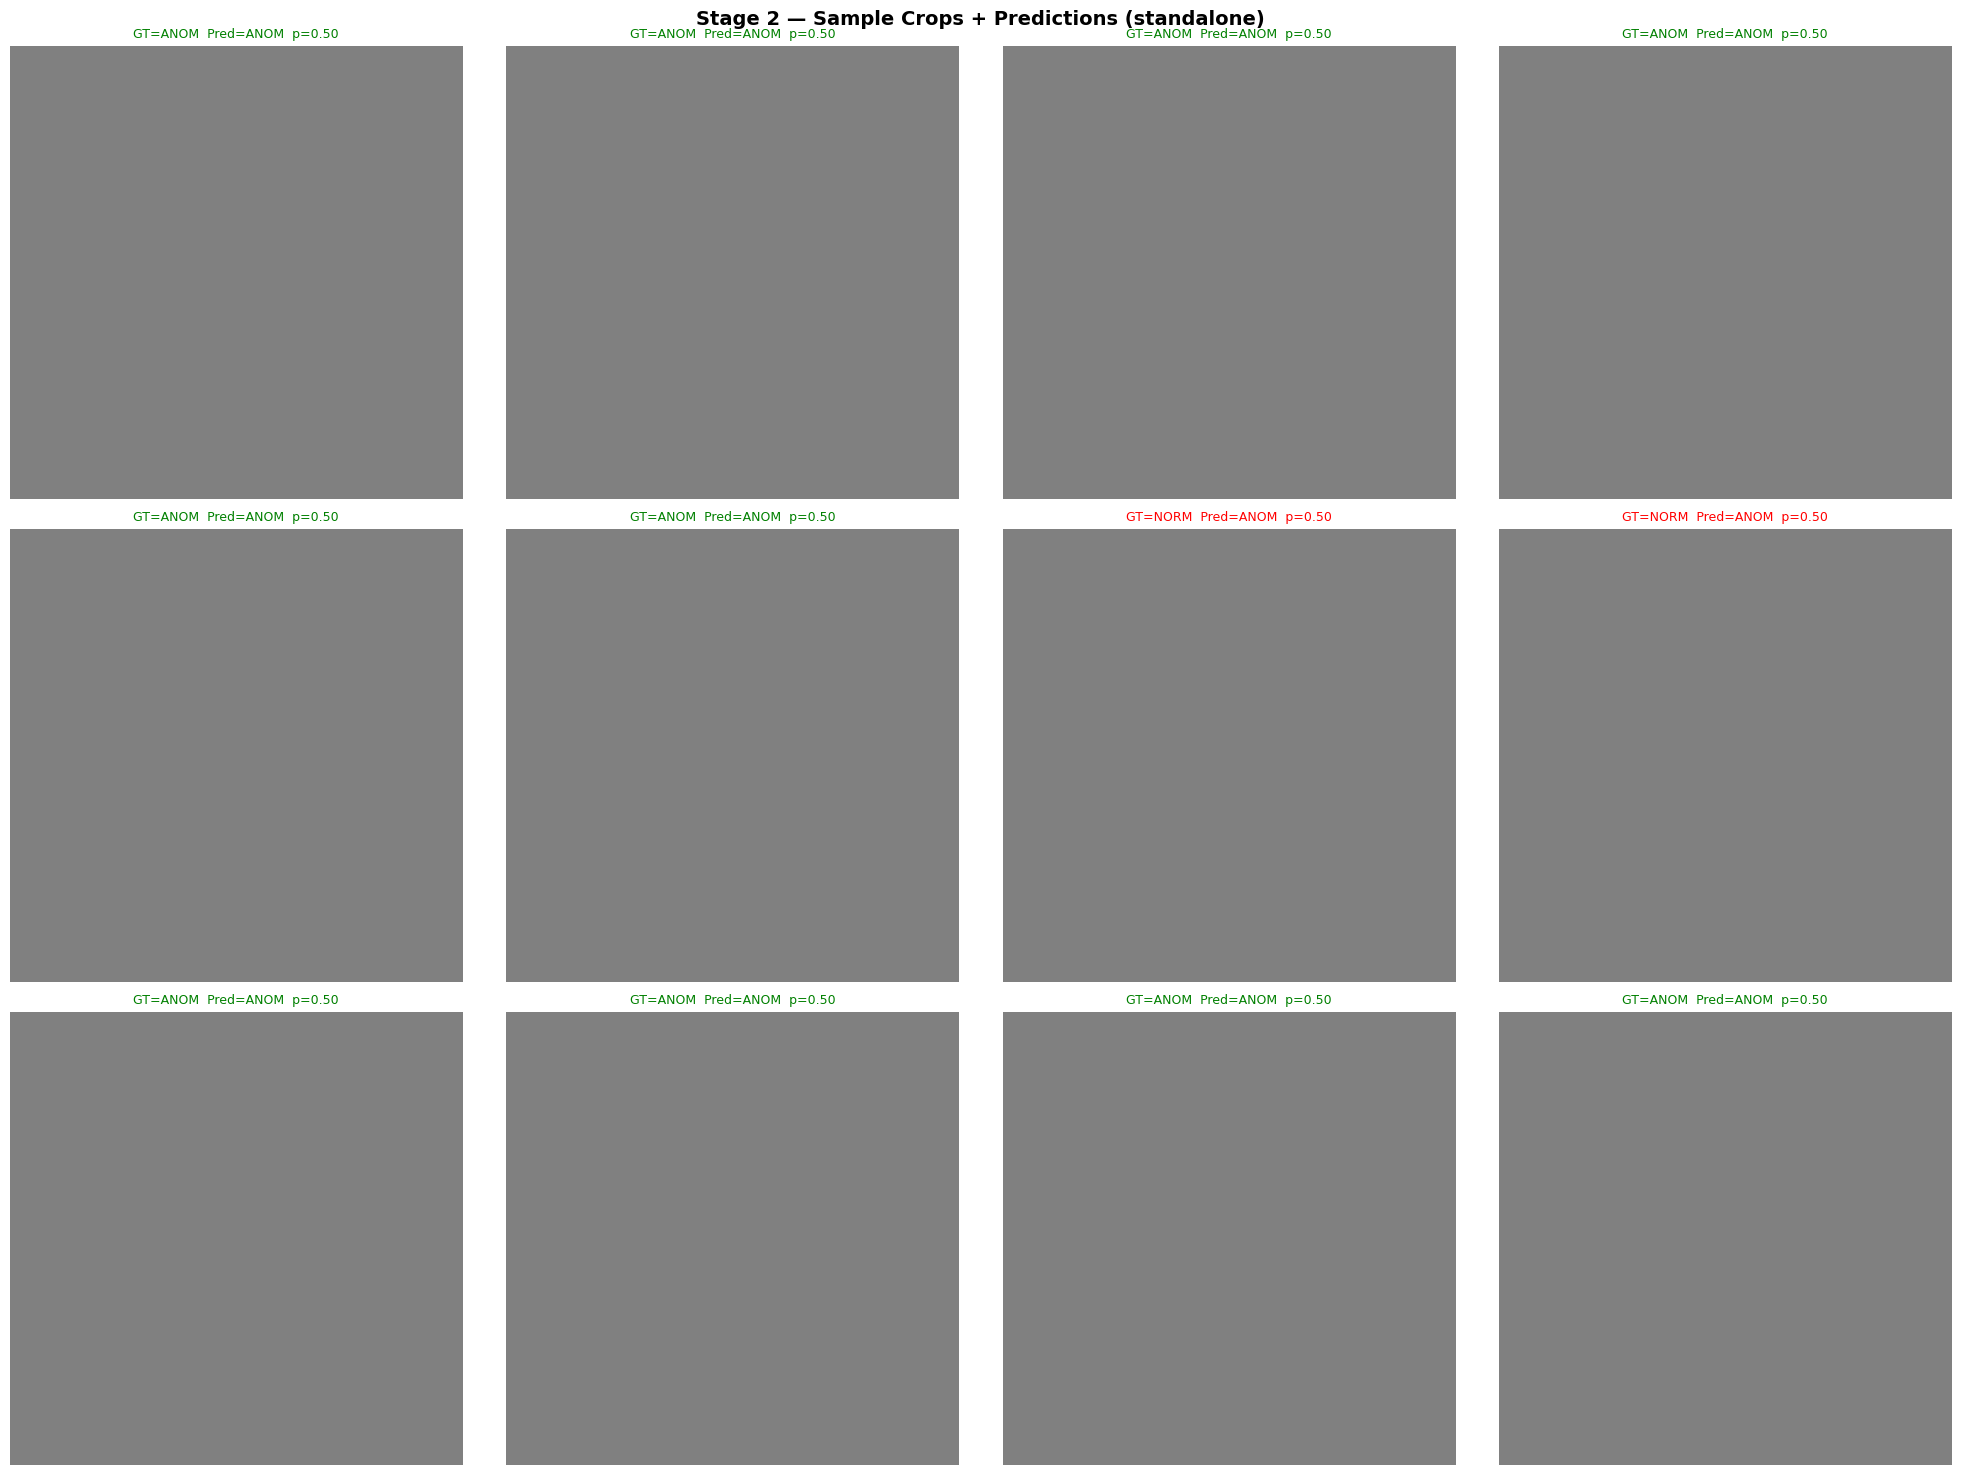

  ✓ Saved: /kaggle/working/stage2_sample_predictions.png

  ✓ STAGE 2 COMPLETE
  Checkpoints : /kaggle/working/stage2_anomaly_best.pth
               /kaggle/working/stage2_anomaly_final.pth
  Report      : /kaggle/working/stage2_report.json
  Curves      : /kaggle/working/stage2_curves.png
  Confusion M : /kaggle/working/stage2_confusion_matrix.png


In [13]:
# ================== CELL 13: RUN FULL PIPELINE ON TEST SAMPLES ==================
# FIX: standalone fallback now iterates a flat global index over test_ds
# so each subplot column shows a DISTINCT crop, not the same crop repeated 4 times.
print('='*60)
print('STAGE 2 — CELL 13: Running full pipeline on test samples')
print('='*60)

# Resolve the Stage 1 model and dataset (may or may not be in memory)
_s1_model   = globals().get('model', None)        # Stage 1 Mask R-CNN
_s1_test_ds = globals().get('test_dataset', None)  # Stage 1 full-image dataset

if _s1_model is None or _s1_test_ds is None:
    print('  ⚠ Stage 1 model / test_dataset not found in session.')
    print('    → Falling back to Stage 2 standalone visualisation on test_ds crops.')
    _USE_PIPELINE = False
else:
    print('  ✓ Stage 1 model and test_dataset found — running full pipeline.')
    _USE_PIPELINE = True

NUM_SAMPLES = min(3, len(_s1_test_ds) if _USE_PIPELINE else len(test_ds))
print(f'  Running on {NUM_SAMPLES} samples')

if _USE_PIPELINE:
    # ── Full Stage 1 → Stage 2 pipeline visualisation ──────────────────
    for i in range(NUM_SAMPLES):
        print(f"\n{'='*60}\n  SAMPLE {i+1} / {NUM_SAMPLES}\n{'='*60}")
        image_tensor, _ = _s1_test_ds[i]
        visualize_pipeline(
            image_tensor=image_tensor,
            stage1_model=_s1_model,
            stage2_model=stage2_model,
            device=device,
            sample_index=i+1
        )
else:
    # ── Standalone Stage 2 visualisation: show crops + predictions ─────
    # Collect NUM_ROWS * COLS_PER_ROW distinct samples from test_ds
    COLS_PER_ROW = 4
    total_needed = NUM_SAMPLES * COLS_PER_ROW
    total_needed = min(total_needed, len(test_ds))

    stage2_model.eval()
    _inv = transforms.Compose([
        transforms.Normalize(
            mean=[-m/s for m, s in zip([0.485,0.456,0.406],[0.229,0.224,0.225])],
            std =[1/s for s in [0.229,0.224,0.225]]
        )
    ])

    # Collect all needed (image, label, prob) tuples in one pass
    collected_imgs, collected_gts, collected_probs = [], [], []
    with torch.no_grad():
        for img_t, lbl_t in test_loader:
            logits = stage2_model(img_t.to(device)).cpu()
            probs  = torch.sigmoid(logits).squeeze(1)
            for j in range(img_t.size(0)):
                if len(collected_imgs) >= total_needed:
                    break
                collected_imgs.append(_inv(img_t[j]).permute(1,2,0).clamp(0,1).numpy())
                collected_gts.append(int(lbl_t[j].item() > 0.5))
                collected_probs.append(float(probs[j].item()))
            if len(collected_imgs) >= total_needed:
                break

    actual_rows = (len(collected_imgs) + COLS_PER_ROW - 1) // COLS_PER_ROW
    fig, axes = plt.subplots(actual_rows, COLS_PER_ROW,
                              figsize=(5 * COLS_PER_ROW, 5 * actual_rows))
    if actual_rows == 1:
        axes = [axes]   # ensure 2-D indexing
    fig.suptitle('Stage 2 — Sample Crops + Predictions (standalone)',
                 fontsize=14, fontweight='bold')

    for flat_idx in range(actual_rows * COLS_PER_ROW):
        row, col = divmod(flat_idx, COLS_PER_ROW)
        ax = axes[row][col]
        if flat_idx < len(collected_imgs):
            ax.imshow(collected_imgs[flat_idx])
            gt   = collected_gts[flat_idx]
            prob = collected_probs[flat_idx]
            pred = int(prob >= CONFIG_S2['binary_threshold'])
            color = 'green' if pred == gt else 'red'
            ax.set_title(
                f"GT={'ANOM' if gt else 'NORM'}  "
                f"Pred={'ANOM' if pred else 'NORM'}  "
                f"p={prob:.2f}",
                color=color, fontsize=9
            )
        ax.axis('off')

    plt.tight_layout()
    out_path = '/kaggle/working/stage2_sample_predictions.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Saved: {out_path}')

print(f"\n{'='*60}")
print('  ✓ STAGE 2 COMPLETE')
print(f'  Checkpoints : {CHECKPOINT_BEST}')
print(f'               {CHECKPOINT_FINAL}')
print(f'  Report      : {REPORT_PATH}')
print(f'  Curves      : /kaggle/working/stage2_curves.png')
print(f'  Confusion M : /kaggle/working/stage2_confusion_matrix.png')
print(f"{'='*60}")